In [1]:
import time
print(time.ctime(time.time()))

Tue Nov 19 13:04:46 2024


In [2]:
import os
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from glob import glob
from pathlib import Path
from tqdm import tqdm


# Paths

In [3]:
# Set paths for main directories
# Main path
path_main = Path(os.path.abspath('')).parent.parent.parent
print(path_main)
# Working path
path_work = Path(os.path.abspath(''))
print(path_work)

/Users/tarry/SCIENCE/git/FaSt-SWOT
/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP


In [4]:
# Data path
path_drifter_L1 = os.path.join(path_main,'data','drifters','L1_IMEDEA')
# Files path
path_files = os.path.join(path_work,'files')

# Read Drifters

In [5]:
# List of files
drifter_files = sorted(glob(os.path.join(path_drifter_L1,'drifter_*')))
print(drifter_files[:5])

['/Users/tarry/SCIENCE/git/FaSt-SWOT/data/drifters/L1_IMEDEA/drifter_carthe006-ime_carthe001.nc', '/Users/tarry/SCIENCE/git/FaSt-SWOT/data/drifters/L1_IMEDEA/drifter_carthe007-ime_carthe002.nc', '/Users/tarry/SCIENCE/git/FaSt-SWOT/data/drifters/L1_IMEDEA/drifter_carthe008-ime_carthe003.nc', '/Users/tarry/SCIENCE/git/FaSt-SWOT/data/drifters/L1_IMEDEA/drifter_carthe009-ime_carthe004.nc', '/Users/tarry/SCIENCE/git/FaSt-SWOT/data/drifters/L1_IMEDEA/drifter_carthe010-ime_carthe005.nc']


In [22]:
# Serial numbers of carthe and hereon for Leg 1 & Leg 2
SN_carthe = [
    '0-4694040','0-4694103','0-4694122','0-4694188','0-4694189',
    '0-4694193','0-4694198','0-4694199','0-4694201','0-4694203',
    '0-4694206','0-4694223','0-4694458','0-4694461','0-4694462',
    '0-4694473','0-4694474','0-4694475','0-4694476','0-4695850'
    ]
SN_hereon = [
    'D-278','D-279','D-280','D-281','D-283',
    'D-284','D-285','D-286','D-287','D-288',
    'D-282','D-289','D-290','D-291','D-292',
    'D-293','D-294','D-295','D-296','D-297'
    ]

In [23]:
# Drifter subsample options
reduce_drifter = True
reduced_sampling_freq = 600

Group all drifters into a single DataFrame

In [25]:
# Concatenate drifter data into unique dataset
id_drifter = 0
for i in tqdm(range(len(drifter_files))):
    dst = xr.open_dataset(drifter_files[i])
    sn_drifter = dst.attrs['instrument_serial']
    if sn_drifter in SN_carthe:
        drifter_label = 'carthe'
    elif sn_drifter in SN_hereon:
        drifter_label = 'hereon'
    else:
        continue
    if reduce_drifter:
        dst = dst.resample(time=f"{int(reduced_sampling_freq)}s").interpolate("linear")
    dft = dst.to_dataframe()[['LAT','LON','U','V']]
    dft.insert(4,'i',np.full(len(dft),fill_value=id_drifter))
    dft.insert(5,'type',[drifter_label]* len(dft))
    if i==0: # Initialize concatenated dataframe
        df_drifters = dft
    else: # Concatenate following drifters
        df_drifters = pd.concat([df_drifters,dft])
    id_drifter += 1
# Remove NaN velocity rows
df_drifters = df_drifters.dropna()
df_drifters

100%|██████████| 40/40 [00:00<00:00, 69.60it/s]


,LAT,LON,U,V,i,type
time,,,,,,
2023-04-26 10:20:00,39.646747,1.422510,-0.034984,0.053404,0,carthe
2023-04-26 10:30:00,39.647035,1.422265,-0.052946,0.081705,0,carthe
2023-04-26 10:40:00,39.647476,1.421894,-0.064663,0.101492,0,carthe
2023-04-26 10:50:00,39.648024,1.421441,-0.070641,0.113436,0,carthe
2023-04-26 11:00:00,39.648636,1.420946,-0.073206,0.120681,0,carthe
...,...,...,...,...,...,...
2023-05-25 18:10:00,39.106813,1.541232,-0.040168,0.039612,39,hereon
2023-05-25 18:20:00,39.107027,1.540953,-0.030380,0.050173,39,hereon
2023-05-25 18:30:00,39.107298,1.540742,-0.020701,0.056198,39,hereon


In [26]:
# Sanity check, drifter amount should be 40
len(df_drifters['i'].unique())

40

Latest deployment is on 10/05/2023 5:37

In [10]:
# Potential start time of the analisis
t_start = pd.Timestamp(2023,5,10,6)
# Drifter location at that time
df_t0 = df_drifters[df_drifters.index==t_start]
df_t0

,LAT,LON,U,V,i,type
time,,,,,,
2023-05-10 06:00:00,40.113126,1.271143,-0.223315,-0.203569,0,carthe
2023-05-10 06:00:00,39.875958,1.245958,-0.341578,-0.123098,2,carthe
2023-05-10 06:00:00,39.698438,1.625839,-0.450255,-0.211386,4,carthe
2023-05-10 06:00:00,40.092123,1.205337,-0.136653,-0.398180,6,carthe
2023-05-10 06:00:00,39.788729,1.610298,-0.229943,-0.370221,7,carthe
2023-05-10 06:00:00,40.120306,1.337804,-0.225821,-0.253718,8,carthe
2023-05-10 06:00:00,39.668943,1.667759,-0.325765,-0.080909,10,carthe
2023-05-10 06:00:00,39.656414,1.809773,-0.089409,0.153724,11,carthe
2023-05-10 06:00:00,39.646313,1.536468,-0.520156,-0.333899,12,carthe


In [11]:
len(df_t0)

35

# Plots

## 3-day trajectory from deployment

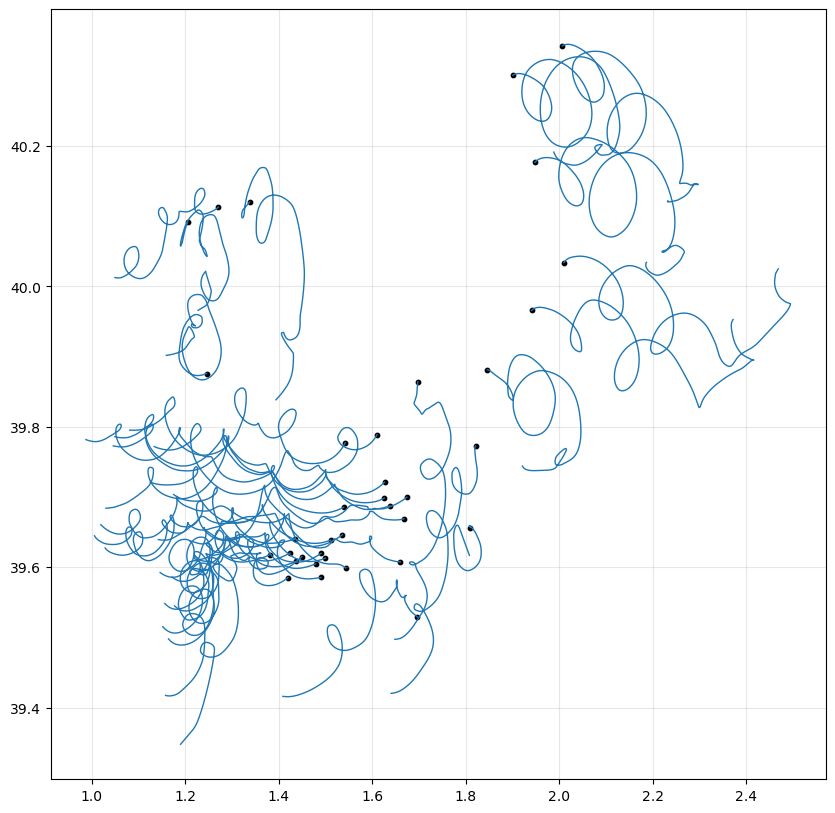

In [42]:
fig,ax = plt.subplots(figsize=(10,10),dpi=100)
for i in range(40):
    drifter = df_drifters[(df_drifters.index>=t_start) & (df_drifters['i']==i)]
    t3 = t_start + pd.Timedelta('3 days')
    drifter = drifter[drifter.index<=t3]
    if len(drifter)==0:
        continue
    ax.plot(drifter['LON'],drifter['LAT'],c='C0',lw=1)
    ax.scatter(drifter['LON'].iloc[0],drifter['LAT'].iloc[0],s=10,c='k')
#ax.scatter(df_t0['LON'],df_t0['LAT'],s=10,c='r')
ax.grid(alpha=0.3)

## 5-day trajectory from deployment

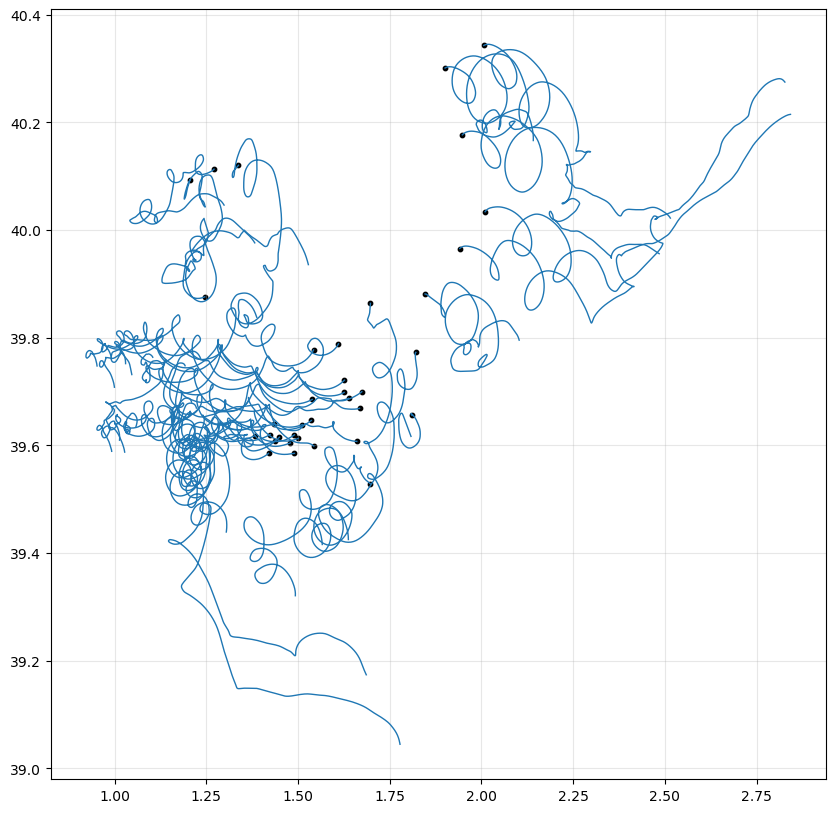

In [43]:
fig,ax = plt.subplots(figsize=(10,10),dpi=100)
for i in range(40):
    drifter = df_drifters[(df_drifters.index>=t_start) & (df_drifters['i']==i)]
    t3 = t_start + pd.Timedelta('5 days')
    drifter = drifter[drifter.index<=t3]
    if len(drifter)==0:
        continue
    ax.plot(drifter['LON'],drifter['LAT'],c='C0',lw=1)
    ax.scatter(drifter['LON'].iloc[0],drifter['LAT'].iloc[0],s=10,c='k')
#ax.scatter(df_t0['LON'],df_t0['LAT'],s=10,c='r')
ax.grid(alpha=0.3)

# Safe final dataframe

In [44]:
fname = 'drifters_DKP_Leg2.parquet'
fpath = os.path.join(path_files,fname)
df_drifters.to_parquet(fpath, engine='pyarrow', compression='gzip')  # or 'fastparquet'
